# Titanic — ¿Quién sobrevivió?

Problema de **clasificación binaria**: a partir de las características de cada pasajero
(`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `Name`, `Cabin`, `Ticket`)
predecir `Survived` (1 = sobrevivió, 0 = no).

Datos: <https://www.kaggle.com/c/titanic/data> (`train.csv` con etiqueta, 891 filas;
`test.csv` sin etiqueta, 418 filas). Métrica oficial de la competencia: **accuracy**.

Estructura:
1. Carga y exploración (EDA)
2. Tratamiento de faltantes e ingeniería de variables
3. Modelos: línea base y comparación con validación cruzada
4. Ajuste de hiperparámetros
5. Evaluación en hold-out, importancia de variables
6. Modelo final y archivo de envío a Kaggle

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (StratifiedKFold, cross_validate, GridSearchCV,
                                     train_test_split)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

SEED = 42                      # semilla fija => resultados reproducibles
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="deep")
FIG = Path("figs"); FIG.mkdir(exist_ok=True)
OUT = Path("output"); OUT.mkdir(exist_ok=True)

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIG / f"{nombre}.png", dpi=130, bbox_inches="tight")
    plt.show()

## 1. Carga y primera inspección

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
train.head()

train: (891, 12)  test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
faltantes = pd.DataFrame({
    "train_n": train.isna().sum(), "train_%": (train.isna().mean() * 100).round(1),
    "test_n": test.isna().sum(),
}).query("train_n > 0 or test_n > 0")
faltantes

,train_n,train_%,test_n
Age,177,19.9,86.0
Cabin,687,77.1,327.0
Embarked,2,0.2,0.0
Fare,0,0.0,1.0


**Observaciones**
- `Age` falta en ~20% de los registros → hay que imputar (es una variable relevante).
- `Cabin` falta en ~77% → no se puede imputar con sentido; se usará sólo *si tiene o no cabina registrada* y la cubierta (primera letra).
- `Embarked` falta en 2 filas y `Fare` en 1 fila de test → imputación simple (moda / mediana).

In [5]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
tasa = train["Survived"].mean()
print(f"Tasa global de supervivencia: {tasa:.3f}  ({train.Survived.sum()} de {len(train)})")

Tasa global de supervivencia: 0.384  (342 de 891)


La clase positiva es ~38%: hay un desbalance moderado, no extremo. Un modelo que prediga
"nadie sobrevive" ya obtiene ~62% de accuracy — ése es el **piso** que cualquier modelo debe superar.
Por eso, además de accuracy, se reportan ROC-AUC y F1.

## 2. Análisis exploratorio

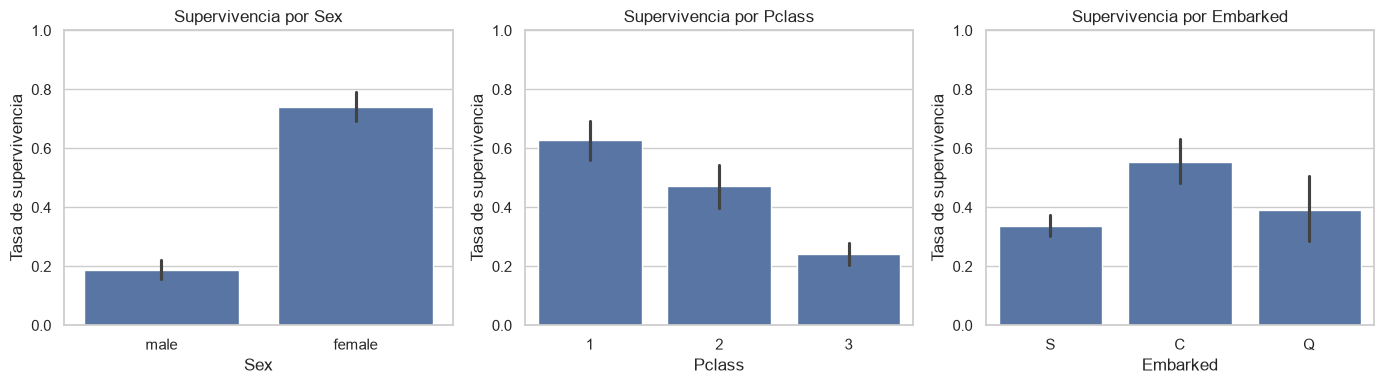

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["Sex", "Pclass", "Embarked"]):
    sns.barplot(data=train, x=col, y="Survived", ax=ax, errorbar=("ci", 95))
    ax.set_ylabel("Tasa de supervivencia"); ax.set_ylim(0, 1)
    ax.set_title(f"Supervivencia por {col}")
guardar("01_sexo_clase_puerto")

In [8]:
pd.crosstab([train.Sex], train.Pclass, values=train.Survived, aggfunc="mean").round(2)

Pclass,1,2,3
Sex,,,
female,0.97,0.92,0.50
male,0.37,0.16,0.14


- **Sexo** es el factor más fuerte: ~74% de las mujeres sobrevivió contra ~19% de los hombres
  (la norma "mujeres y niños primero").
- **Clase**: 1ra ≈ 63%, 2da ≈ 47%, 3ra ≈ 24%. La clase interactúa con el sexo: las mujeres de 1ra y 2da
  sobrevivieron casi todas, las de 3ra sólo ~50%.
- **Puerto**: Cherbourg muestra mayor supervivencia, pero probablemente porque allí embarcaron
  más pasajeros de 1ra clase (variable confundida con `Pclass`).

In [9]:
pd.crosstab(train.Embarked, train.Pclass, normalize="index").round(2)

Pclass,1,2,3
Embarked,,,
C,0.51,0.10,0.39
Q,0.03,0.04,0.94
S,0.20,0.25,0.55


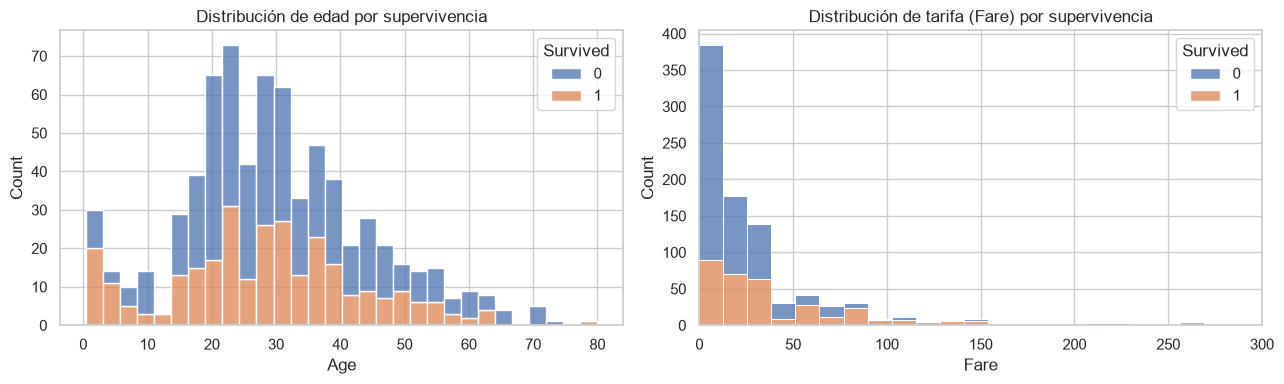

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=train, x="Age", hue="Survived", bins=30, multiple="stack", ax=axes[0])
axes[0].set_title("Distribución de edad por supervivencia")
sns.histplot(data=train, x="Fare", hue="Survived", bins=40, multiple="stack", ax=axes[1],
             log_scale=(False, False))
axes[1].set_xlim(0, 300); axes[1].set_title("Distribución de tarifa (Fare) por supervivencia")
guardar("02_edad_tarifa")

- Los **niños pequeños** (< 10 años) tienen tasas de supervivencia claramente mayores.
- `Fare` está muy sesgada a la derecha (outliers de hasta 512) y se relaciona con la clase:
  tarifas altas → más supervivencia. Para modelos lineales conviene transformarla con `log1p`.

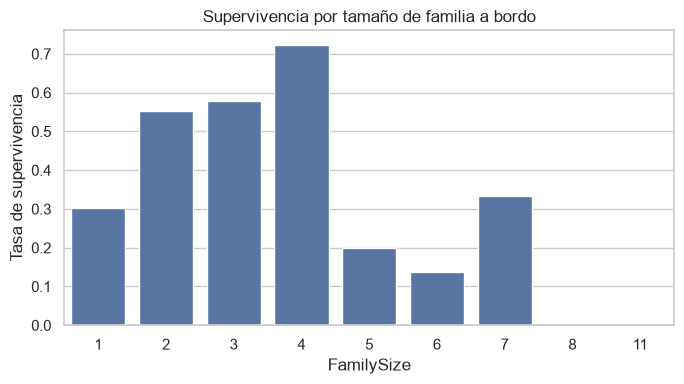

In [11]:
train["FamilySize"] = train.SibSp + train.Parch + 1
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=train, x="FamilySize", y="Survived", ax=ax, errorbar=None)
ax.set_ylabel("Tasa de supervivencia"); ax.set_title("Supervivencia por tamaño de familia a bordo")
guardar("03_familia")
train.drop(columns="FamilySize", inplace=True)

Relación **no lineal** con el tamaño de familia: viajar solo (1) o en familias grandes (≥5) reduce la
supervivencia; familias de 2 a 4 tienen la mayor tasa. Esto motiva crear `FamilySize` y agruparla.

In [12]:
titulo = train.Name.str.extract(r",\s*([^\.]+)\.")[0]
pd.DataFrame({"n": titulo.value_counts(),
              "tasa": train.groupby(titulo).Survived.mean().round(2)}).sort_values("n", ascending=False)

,n,tasa
0,,
Mr,517,0.16
Miss,182,0.70
Mrs,125,0.79
Master,40,0.57
Dr,7,0.43
Rev,6,0.00
Mlle,2,1.00
Major,2,0.50
Col,2,0.50


El **título** extraído del nombre (`Mr`, `Mrs`, `Miss`, `Master`, …) resume sexo, edad aproximada y
estado civil/estatus. `Master` (niños varones) sobrevive ~57% contra ~16% de `Mr`: captura el efecto
"niños primero" en los varones, algo que `Sex` solo no ve. Los títulos poco frecuentes se agrupan en `Rare`.

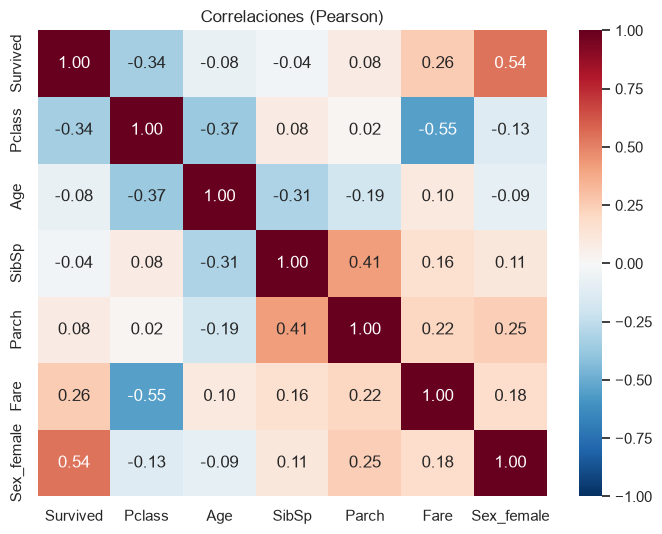

In [13]:
num = train[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].copy()
num["Sex_female"] = (train.Sex == "female").astype(int)
plt.figure(figsize=(7, 5.5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlaciones (Pearson)")
guardar("04_correlaciones")

## 3. Ingeniería de variables y tratamiento de faltantes

Decisión clave: **todo el preprocesamiento vive dentro de un `Pipeline` de scikit-learn**. Así, los
valores aprendidos (p. ej. la mediana de edad por título) se calculan sólo con los datos de
entrenamiento de cada *fold* de validación cruzada, y se evita la **fuga de información (data leakage)**
del conjunto de validación hacia el modelo.

Variables creadas:

| Variable | Cómo se construye | Justificación |
|---|---|---|
| `Title` | Texto entre la coma y el punto en `Name`; títulos raros → `Rare`, `Mlle/Ms`→`Miss`, `Mme`→`Mrs` | Resume sexo + edad + estatus |
| `FamilySize` | `SibSp + Parch + 1` | Efecto no lineal observado |
| `FamilyGroup` | Solo (1) / Chica (2–4) / Grande (≥5) | Captura la forma de U invertida |
| `HasCabin` | 1 si `Cabin` no es nulo | Proxy de estatus; 77% faltante impide usar el valor |
| `Deck` | Primera letra de `Cabin` (o `U` = desconocida) | Ubicación física en el barco |
| `AgeImp` | `Age` imputada con la mediana **por título** | Más precisa que la mediana global (un `Master` no tiene 28 años) |
| `AgeMissing` | 1 si la edad era nula | Que falte el dato puede ser informativo |
| `IsChild` | `AgeImp < 13` | Umbral de "niños primero" |
| `LogFare` | `log1p(Fare)`, faltantes → mediana por clase | Reduce el sesgo de la distribución |
| `TicketGroup` | Cantidad de pasajeros que comparten el mismo ticket | Grupos que viajaban juntos (amigos, servicio) |

Se **descartan** `PassengerId` (identificador), `Name` y `Ticket` crudos (texto de alta cardinalidad ya
resumido en `Title` y `TicketGroup`) y `Cabin` cruda.

In [14]:
TITULOS_MAP = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
TITULOS_OK = {"Mr", "Mrs", "Miss", "Master"}

class TitanicFeatures(BaseEstimator, TransformerMixin):
    """Crea las variables derivadas. fit() aprende sólo del conjunto que recibe."""

    def fit(self, X, y=None):
        X = self._basicas(X)
        self.age_med_title_ = X.groupby("Title").Age.median()
        self.age_med_ = X.Age.median()
        self.fare_med_class_ = X.groupby("Pclass").Fare.median()
        self.embarked_mode_ = X.Embarked.mode()[0]
        self.ticket_counts_ = X.Ticket.value_counts()
        return self

    @staticmethod
    def _basicas(X):
        X = X.copy()
        t = X.Name.str.extract(r",\s*([^\.]+)\.")[0].str.strip().replace(TITULOS_MAP)
        X["Title"] = t.where(t.isin(TITULOS_OK), "Rare")
        return X

    def transform(self, X):
        X = self._basicas(X)
        X["FamilySize"] = X.SibSp + X.Parch + 1
        X["FamilyGroup"] = pd.cut(X.FamilySize, [0, 1, 4, 20],
                                  labels=["Solo", "Chica", "Grande"]).astype(str)
        X["HasCabin"] = X.Cabin.notna().astype(int)
        X["Deck"] = X.Cabin.str[0].fillna("U").replace({"T": "U"})
        X["AgeMissing"] = X.Age.isna().astype(int)
        X["AgeImp"] = X.Age.fillna(X.Title.map(self.age_med_title_)).fillna(self.age_med_)
        X["IsChild"] = (X.AgeImp < 13).astype(int)
        fare = X.Fare.fillna(X.Pclass.map(self.fare_med_class_))
        X["LogFare"] = np.log1p(fare)
        X["Embarked"] = X.Embarked.fillna(self.embarked_mode_)
        X["TicketGroup"] = X.Ticket.map(self.ticket_counts_).fillna(1).clip(upper=5)
        X["Pclass"] = X.Pclass.astype(str)          # se trata como categórica
        return X[NUM + CAT]

NUM = ["AgeImp", "LogFare", "FamilySize", "TicketGroup", "SibSp", "Parch",
       "HasCabin", "AgeMissing", "IsChild"]
CAT = ["Sex", "Pclass", "Title", "Embarked", "FamilyGroup", "Deck"]

def armar_pipeline(modelo, escalar=True):
    prep = ColumnTransformer([
        ("num", StandardScaler() if escalar else "passthrough", NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
    ])
    return Pipeline([("feat", TitanicFeatures()), ("prep", prep), ("model", modelo)])

X = train.drop(columns="Survived")
y = train.Survived
TitanicFeatures().fit(X).transform(X).head()

,AgeImp,LogFare,FamilySize,TicketGroup,SibSp,Parch,HasCabin,AgeMissing,IsChild,Sex,Pclass,Title,Embarked,FamilyGroup,Deck
0,22.0,2.110213,2,1,1,0,0,0,0,male,3,Mr,S,Chica,U
1,38.0,4.280593,2,1,1,0,1,0,0,female,1,Mrs,C,Chica,C
2,26.0,2.188856,1,1,0,0,0,0,0,female,3,Miss,S,Solo,U
3,35.0,3.990834,2,2,1,0,1,0,0,female,1,Mrs,S,Chica,C
4,35.0,2.202765,1,1,0,0,0,0,0,male,3,Mr,S,Solo,U


In [15]:
# Verificación: no quedan nulos luego de la transformación (train y test)
tf = TitanicFeatures().fit(X)
print("Nulos en train transformado:", tf.transform(X).isna().sum().sum())
print("Nulos en test transformado: ", tf.transform(test).isna().sum().sum())

Nulos en train transformado: 0
Nulos en test transformado:  0


## 4. Modelos: línea base y comparación

**Protocolo de evaluación**
- Se reserva un **20% estratificado como hold-out** que no se toca hasta el final: sirve para una
  estimación honesta luego de elegir y ajustar el modelo.
- Sobre el 80% restante se usa **validación cruzada estratificada de 10 folds** para comparar modelos.
  Con sólo ~700 filas, una única partición train/validación daría estimaciones muy ruidosas; la CV
  promedia 10 estimaciones y permite ver la variabilidad (desvío estándar).
- Se compara contra dos líneas base: la clase mayoritaria y la regla "todas las mujeres sobreviven".

In [16]:
X_tr, X_ho, y_tr, y_ho = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
print(len(X_tr), "filas para CV  |", len(X_ho), "filas de hold-out")

712 filas para CV  | 179 filas de hold-out


In [17]:
# Línea base "género": predice sobrevive si es mujer
base_genero = (X_tr.Sex == "female").astype(int)
print(f"Base clase mayoritaria : {1 - y_tr.mean():.3f}")
print(f"Base 'mujeres viven'   : {accuracy_score(y_tr, base_genero):.3f}")

Base clase mayoritaria : 0.617
Base 'mujeres viven'   : 0.789


In [18]:
modelos = {
    "Regresión logística": (LogisticRegression(max_iter=2000), True),
    "KNN (k=7)":           (KNeighborsClassifier(n_neighbors=7), True),
    "SVM (RBF)":           (SVC(probability=True, random_state=SEED), True),
    "Árbol de decisión":   (DecisionTreeClassifier(random_state=SEED), False),
    "Random Forest":       (RandomForestClassifier(n_estimators=300, random_state=SEED), False),
    "Gradient Boosting":   (GradientBoostingClassifier(random_state=SEED), False),
}
filas = []
for nombre, (m, esc) in modelos.items():
    r = cross_validate(armar_pipeline(m, esc), X_tr, y_tr, cv=cv,
                       scoring=["accuracy", "roc_auc", "f1"], return_train_score=True)
    filas.append({"Modelo": nombre,
                  "Acc train": r["train_accuracy"].mean(),
                  "Acc CV": r["test_accuracy"].mean(), "± desv": r["test_accuracy"].std(),
                  "AUC CV": r["test_roc_auc"].mean(), "F1 CV": r["test_f1"].mean()})
comparacion = pd.DataFrame(filas).set_index("Modelo").sort_values("Acc CV", ascending=False).round(3)
comparacion["Brecha (sobreajuste)"] = (comparacion["Acc train"] - comparacion["Acc CV"]).round(3)
comparacion.to_csv(OUT / "comparacion_modelos.csv")
comparacion

,Acc train,Acc CV,± desv,AUC CV,F1 CV,Brecha (sobreajuste)
Modelo,,,,,,
SVM (RBF),0.849,0.827,0.039,0.872,0.766,0.022
Regresión logística,0.840,0.822,0.040,0.873,0.764,0.018
Gradient Boosting,0.916,0.822,0.038,0.889,0.753,0.094
Random Forest,0.988,0.816,0.022,0.867,0.754,0.172
KNN (k=7),0.851,0.810,0.032,0.862,0.744,0.041
Árbol de decisión,0.988,0.791,0.045,0.778,0.726,0.197


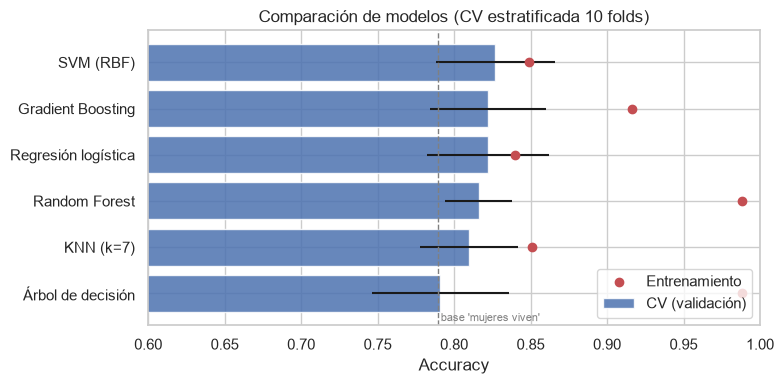

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
c = comparacion.sort_values("Acc CV")
ax.barh(c.index, c["Acc CV"], xerr=c["± desv"], color="#4C72B0", alpha=.85, label="CV (validación)")
ax.scatter(c["Acc train"], c.index, color="#C44E52", zorder=3, label="Entrenamiento")
base = accuracy_score(y_tr, base_genero)
ax.axvline(base, ls="--", color="gray", lw=1); ax.text(base + 0.002, -0.6, "base 'mujeres viven'", fontsize=8, color="gray")
ax.set_xlim(0.6, 1.0); ax.set_xlabel("Accuracy"); ax.legend(loc="lower right")
ax.set_title("Comparación de modelos (CV estratificada 10 folds)")
guardar("05_comparacion_modelos")

**Primer problema encontrado: sobreajuste.** El árbol de decisión sin restricciones (y en menor medida
Random Forest) llega a ~98% en entrenamiento pero cae mucho en validación: memoriza el conjunto de
entrenamiento. La columna *Brecha* lo cuantifica. Esto se corrige limitando la complejidad
(profundidad máxima, mínimo de muestras por hoja), que es lo que se busca en el paso siguiente.

## 5. Ajuste de hiperparámetros

Se ajustan con `GridSearchCV` (misma CV de 10 folds, sólo sobre el 80% de entrenamiento) los tres
candidatos más prometedores y de naturaleza distinta: un modelo lineal (interpretable), un ensamble por
*bagging* y uno por *boosting*.

In [20]:
grillas = {
    "Regresión logística": (armar_pipeline(LogisticRegression(max_iter=2000)),
        {"model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}),
    "Random Forest": (armar_pipeline(RandomForestClassifier(n_estimators=300, random_state=SEED), False),
        {"model__max_depth": [4, 6, 8, None], "model__min_samples_leaf": [1, 3, 5],
         "model__max_features": ["sqrt", 0.5]}),
    "Gradient Boosting": (armar_pipeline(GradientBoostingClassifier(random_state=SEED), False),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.03, 0.1],
         "model__max_depth": [2, 3, 4], "model__subsample": [0.8, 1.0]}),
}
ajustados, filas = {}, []
for nombre, (pipe, grid) in grillas.items():
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy", n_jobs=-1, return_train_score=True)
    gs.fit(X_tr, y_tr)
    ajustados[nombre] = gs.best_estimator_
    i = gs.best_index_
    filas.append({"Modelo": nombre, "Mejores parámetros": {k.replace("model__", ""): v for k, v in gs.best_params_.items()},
                  "Acc train": gs.cv_results_["mean_train_score"][i],
                  "Acc CV": gs.best_score_, "± desv": gs.cv_results_["std_test_score"][i]})
tuning = pd.DataFrame(filas).set_index("Modelo").round(3)
tuning.to_csv(OUT / "tuning.csv")
tuning

,Mejores parámetros,Acc train,Acc CV,± desv
Modelo,,,,
Regresión logística,{'C': 0.1},0.833,0.826,0.026
Random Forest,"{'max_depth': 4, 'max_features': 0.5, 'min_sam...",0.849,0.841,0.037
Gradient Boosting,"{'learning_rate': 0.03, 'max_depth': 2, 'n_est...",0.846,0.837,0.041


## 6. Evaluación final en el hold-out

Recién ahora se usan las 179 filas reservadas. Es la estimación más honesta del desempeño en datos nuevos,
porque no intervinieron en ninguna decisión.

In [21]:
filas = []
for nombre, m in ajustados.items():
    p = m.predict(X_ho); pr = m.predict_proba(X_ho)[:, 1]
    filas.append({"Modelo": nombre, "Accuracy": accuracy_score(y_ho, p),
                  "ROC-AUC": roc_auc_score(y_ho, pr)})
holdout = pd.DataFrame(filas).set_index("Modelo").round(3)
holdout.loc["Base 'mujeres viven'"] = [accuracy_score(y_ho, (X_ho.Sex == "female").astype(int)), np.nan]
holdout.to_csv(OUT / "holdout.csv")
holdout

,Accuracy,ROC-AUC
Modelo,,
Regresión logística,0.832000,0.867
Random Forest,0.827000,0.847
Gradient Boosting,0.799000,0.842
Base 'mujeres viven',0.776536,NaN


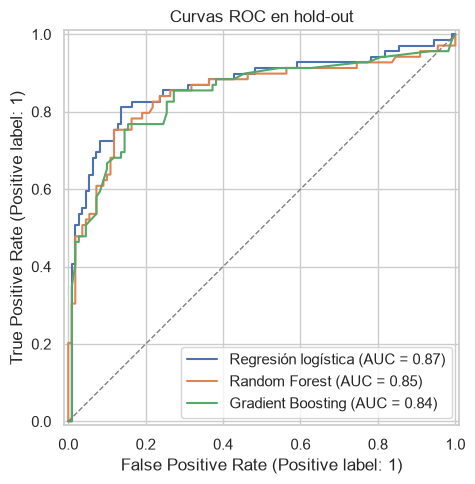

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
for nombre, m in ajustados.items():
    RocCurveDisplay.from_estimator(m, X_ho, y_ho, name=nombre, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
ax.set_title("Curvas ROC en hold-out")
guardar("06_roc")

Modelo elegido (mejor accuracy en CV): Random Forest
               precision    recall  f1-score   support

No sobrevivió      0.843     0.882     0.862       110
   Sobrevivió      0.797     0.739     0.767        69

     accuracy                          0.827       179
    macro avg      0.820     0.810     0.815       179
 weighted avg      0.826     0.827     0.825       179



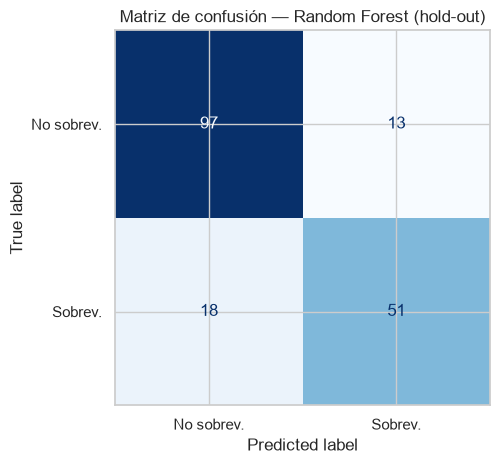

In [23]:
MEJOR = tuning["Acc CV"].idxmax()     # se elige por CV, no por hold-out (evita "espiar" el test)
print("Modelo elegido (mejor accuracy en CV):", MEJOR)
m = ajustados[MEJOR]
pred = m.predict(X_ho)
print(classification_report(y_ho, pred, target_names=["No sobrevivió", "Sobrevivió"], digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_ho, pred),
                       display_labels=["No sobrev.", "Sobrev."]).plot(cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión — {MEJOR} (hold-out)")
guardar("07_confusion")

Lectura de la matriz de confusión: los errores más frecuentes suelen ser **sobrevivientes predichos como
no sobrevivientes** (falsos negativos), típicamente hombres adultos que sobrevivieron o mujeres de 3ra
clase que no: casos que contradicen el patrón dominante y que con estas variables no se pueden distinguir.

## 7. ¿Qué características determinan la supervivencia?

Se usan dos enfoques complementarios:
1. **Coeficientes de la regresión logística** (variables estandarizadas): signo = dirección del efecto,
   magnitud = fuerza; `exp(coef)` es el *odds ratio*.
2. **Importancia por permutación** en el hold-out: cuánto cae la accuracy si se "desordena" una variable
   original. Es agnóstica al modelo y se mide sobre datos no vistos.

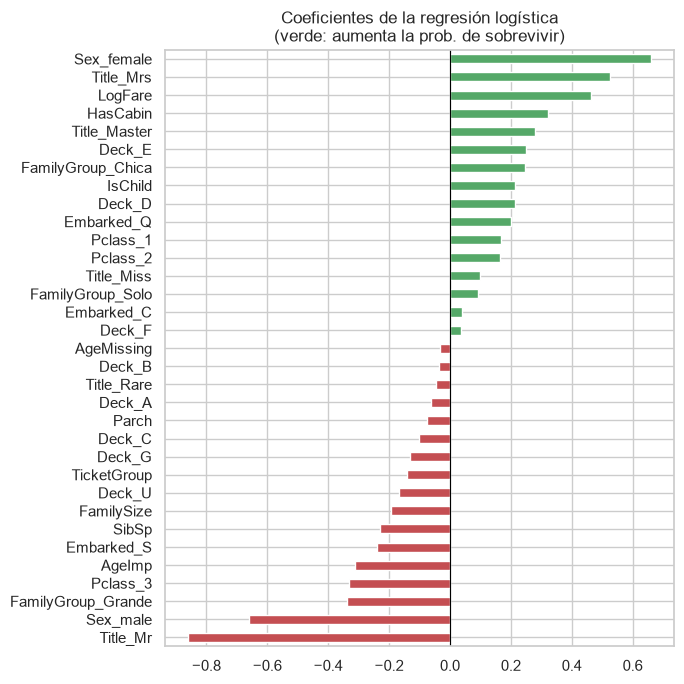

In [24]:
lr = ajustados["Regresión logística"]
nombres = lr.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lr.named_steps["model"].coef_[0],
                  index=[n.split("__")[1] for n in nombres]).sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
coefs.plot.barh(ax=ax, color=np.where(coefs > 0, "#55A868", "#C44E52"))
ax.axvline(0, color="black", lw=.8)
ax.set_title("Coeficientes de la regresión logística\n(verde: aumenta la prob. de sobrevivir)")
guardar("08_coeficientes_lr")
coefs.to_frame("coef").assign(odds_ratio=np.exp(coefs)).round(3).to_csv(OUT / "coeficientes_lr.csv")

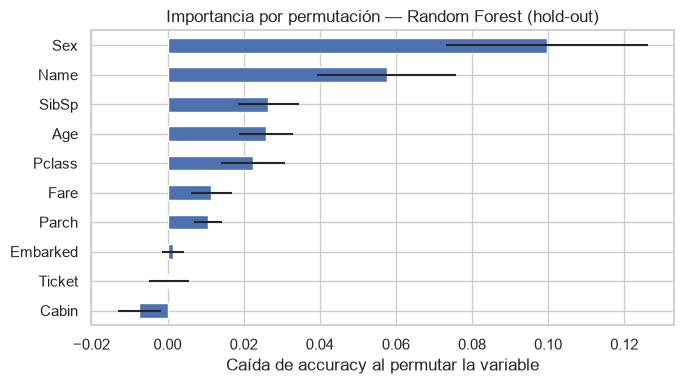

,media,desv
Sex,0.0996,0.0265
Name,0.0575,0.0181
SibSp,0.0264,0.0080
Age,0.0259,0.0070
Pclass,0.0223,0.0084
Fare,0.0115,0.0054
Parch,0.0106,0.0036
Embarked,0.0015,0.0029
Ticket,0.0004,0.0052
Cabin,-0.0074,0.0056


In [25]:
imp = permutation_importance(ajustados[MEJOR], X_ho, y_ho, n_repeats=30,
                             random_state=SEED, scoring="accuracy")
importancia = (pd.DataFrame({"media": imp.importances_mean, "desv": imp.importances_std}, index=X_ho.columns)
               .sort_values("media", ascending=False))
importancia = importancia[importancia.media.abs() > 0]
fig, ax = plt.subplots(figsize=(7, 4))
importancia.sort_values("media").plot.barh(y="media", xerr="desv", ax=ax, legend=False, color="#4C72B0")
ax.set_xlabel("Caída de accuracy al permutar la variable")
ax.set_title(f"Importancia por permutación — {MEJOR} (hold-out)")
guardar("09_importancia_permutacion")
importancia.round(4).to_csv(OUT / "importancia_permutacion.csv")
importancia.round(4)

La permutación se hace sobre las **columnas originales** (antes de la ingeniería de variables). Por eso
`Name` aparece como la segunda más importante: al desordenarla se rompe `Title`. `SibSp`/`Parch` alimentan
`FamilySize`, y `Fare`/`Cabin` son reflejo de la clase. Un valor ≈ 0 o negativo (`Ticket`, `Cabin`,
`Embarked`) indica que el modelo prácticamente no depende de esa variable en datos nuevos.

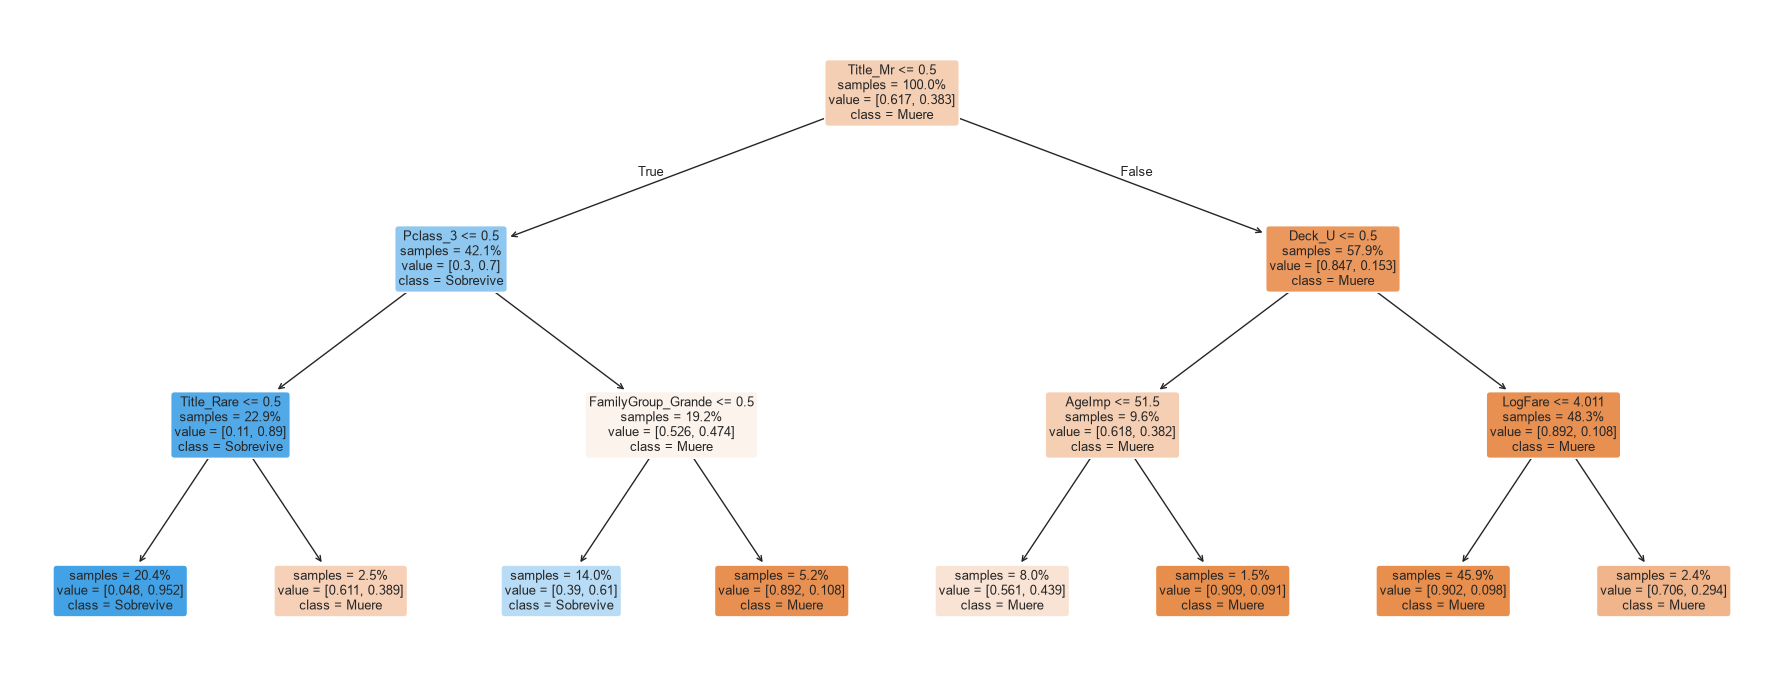

Accuracy hold-out del árbol de profundidad 3: 0.832


In [26]:
# Árbol poco profundo: una visualización interpretable de las reglas principales
arbol = armar_pipeline(DecisionTreeClassifier(max_depth=3, random_state=SEED), False).fit(X_tr, y_tr)
nombres_arbol = [n.split("__")[1] for n in arbol.named_steps["prep"].get_feature_names_out()]
plt.figure(figsize=(18, 7))
plot_tree(arbol.named_steps["model"], feature_names=nombres_arbol, class_names=["Muere", "Sobrevive"],
          filled=True, rounded=True, fontsize=9, impurity=False, proportion=True)
guardar("10_arbol_reglas")
print(f"Accuracy hold-out del árbol de profundidad 3: {arbol.score(X_ho, y_ho):.3f}")

## 8. Modelo final y envío a Kaggle

Una vez elegido el modelo y sus hiperparámetros, se **reentrena con las 891 filas** (más datos → mejor
modelo) y se predice `test.csv`. El archivo `output/submission.csv` tiene el formato que pide Kaggle
(`PassengerId,Survived`).

In [27]:
final = ajustados[MEJOR]
final.fit(X, y)
sub = pd.DataFrame({"PassengerId": test.PassengerId, "Survived": final.predict(test).astype(int)})
sub.to_csv(OUT / "submission.csv", index=False)
print(sub.shape, "| proporción predicha como sobreviviente:", round(sub.Survived.mean(), 3))
sub.head()

(418, 2) | proporción predicha como sobreviviente: 0.39


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [28]:
# Envíos adicionales con los otros modelos ajustados (para comparar en el leaderboard)
for nombre, m in ajustados.items():
    m.fit(X, y)
    slug = {"Regresión logística": "logistica", "Random Forest": "random_forest",
            "Gradient Boosting": "gradient_boosting"}[nombre]
    archivo = OUT / f"submission_{slug}.csv"
    pd.DataFrame({"PassengerId": test.PassengerId, "Survived": m.predict(test).astype(int)}).to_csv(archivo, index=False)
    print("guardado", archivo)

guardado output\submission_logistica.csv


guardado output\submission_random_forest.csv
guardado output\submission_gradient_boosting.csv


## 9. Conclusiones

- Las variables que más determinan la supervivencia son **sexo / título**, **clase** (y tarifa / cabina,
  que la reflejan) y **edad** (ser niño), seguidas por el **tamaño del grupo familiar**.
- Los ensambles ajustados y la regresión logística quedan en ~82–84% de accuracy en validación, unos
  4–6 puntos sobre la regla trivial "mujeres viven" (~79%). En el leaderboard público de Kaggle, valores de
  0.77–0.80 son habituales para este tipo de enfoque; la diferencia con la CV se debe a que el test es
  pequeño (418 filas) y a la variabilidad propia del problema.
- Problemas enfrentados: datos faltantes (Age, Cabin), variables de texto (Name, Ticket, Cabin), sobreajuste
  de modelos basados en árboles, riesgo de fuga de información en la imputación y dataset pequeño con
  estimaciones ruidosas. Cada uno se trató explícitamente (ver documento).